<h1 align="center">Support Vector Machine (SVM)</h1>

### Problem Statement:  Classify raisins into one of the two categories,
1. Kecimen
1. Besni

In [ ]:
import pandas as pd

df = pd.read_excel("Raisin_Dataset.xlsx")
df.sample(5)

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Perimeter,Class
527,163442,594.759221,351.425687,0.806766,167471,0.704686,1621.959,Besni
333,60313,339.603456,227.725924,0.741851,62130,0.726680,946.487,Kecimen
441,63191,335.241687,243.972390,0.685842,64898,0.704604,977.095,Kecimen
318,66094,323.187716,261.011911,0.589707,67032,0.738720,944.713,Kecimen
830,125968,522.543776,308.047596,0.807757,129444,0.739579,1414.078,Besni


In [ ]:
df.shape

(900, 8)

###Exploratory Data Analysis (EDA)

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt


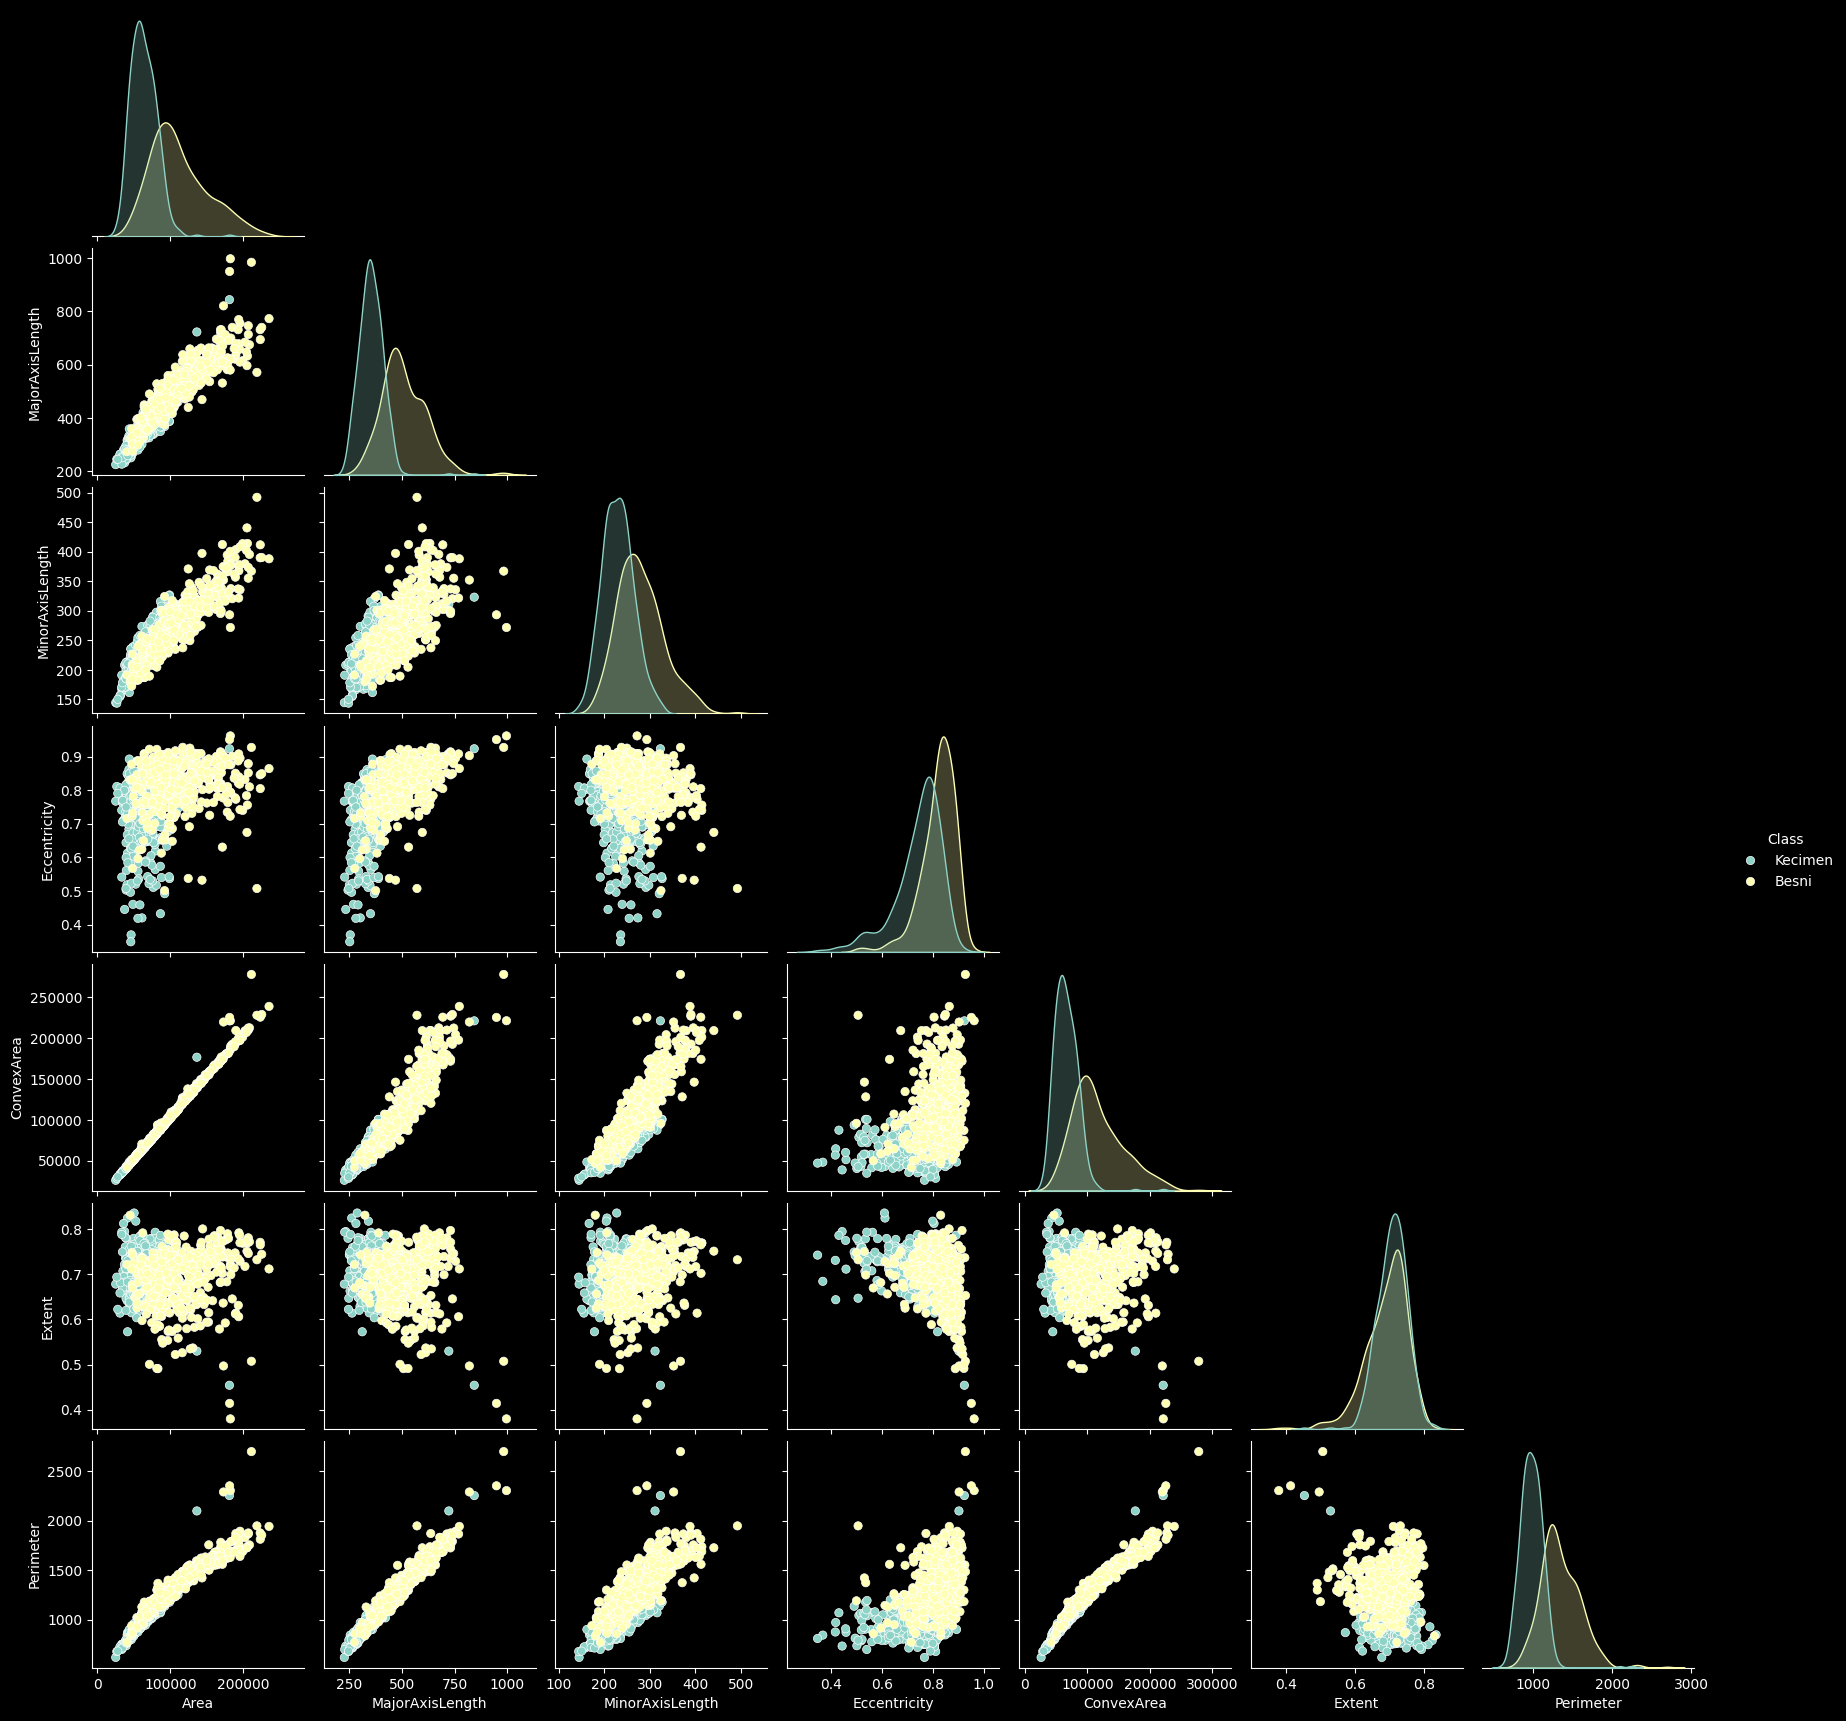

In [ ]:
sns.pairplot(df, hue='Class', corner=True, diag_kind='kde')

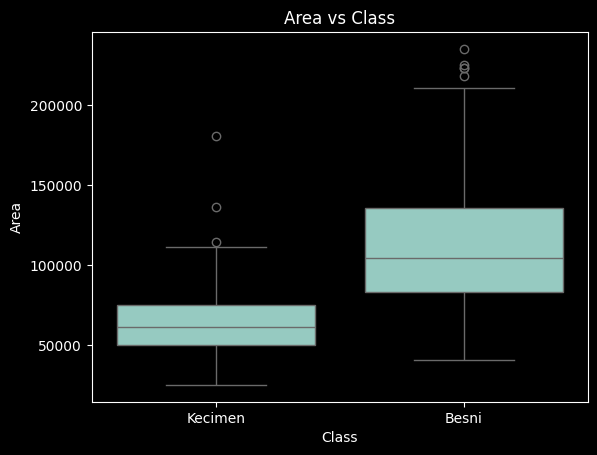

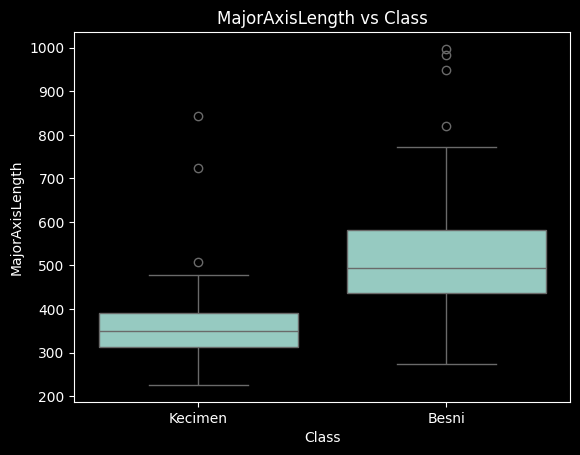

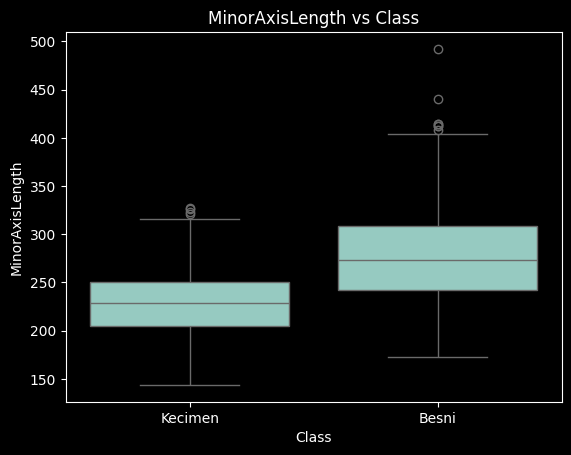

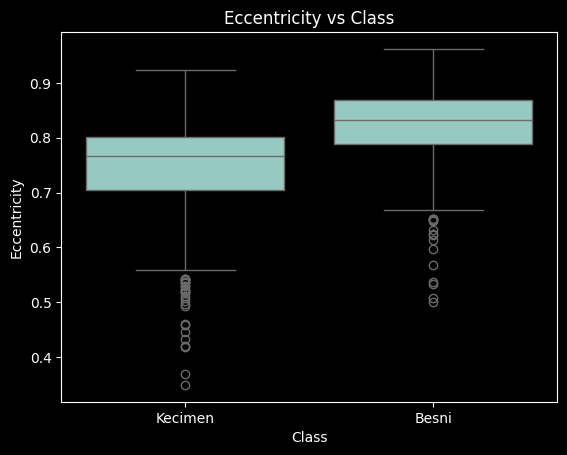

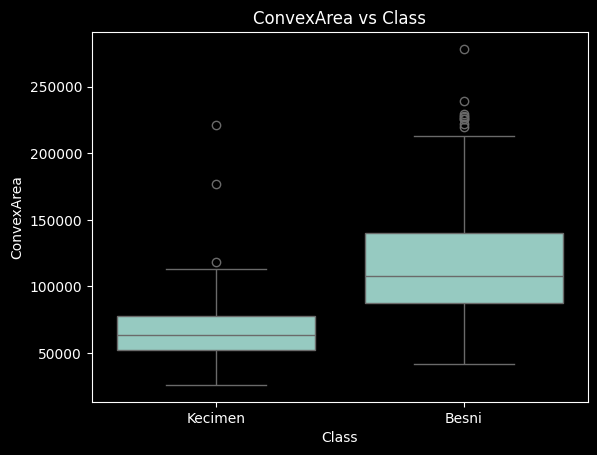

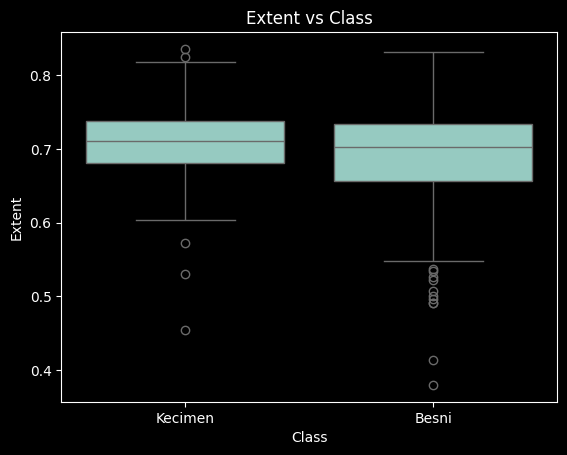

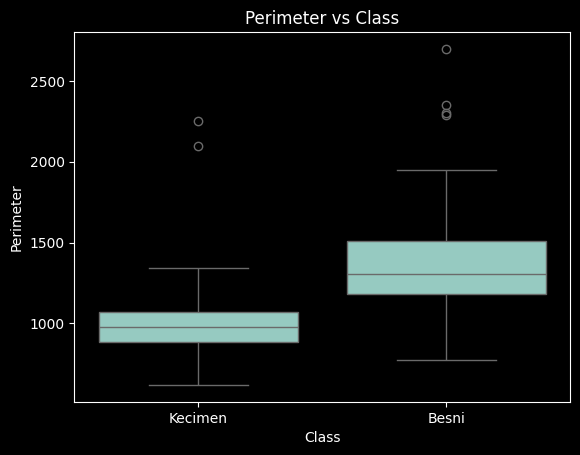

In [ ]:
for col in df.columns[:-1]:
    sns.boxplot(x='Class', y=col, data=df)
    plt.title(f"{col} vs Class")
    plt.show()

<Axes: >

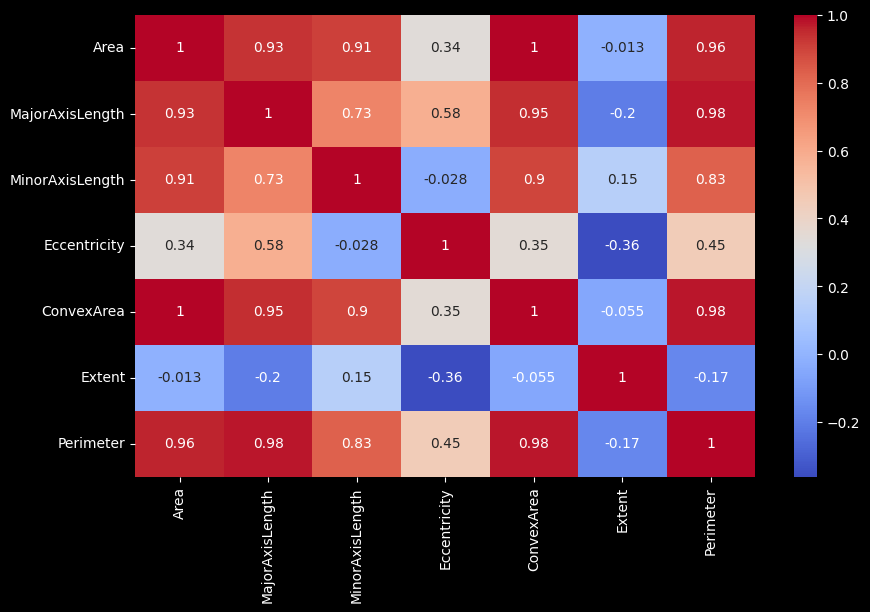

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df.drop('Class', axis=1).corr(), annot=True, cmap='coolwarm')

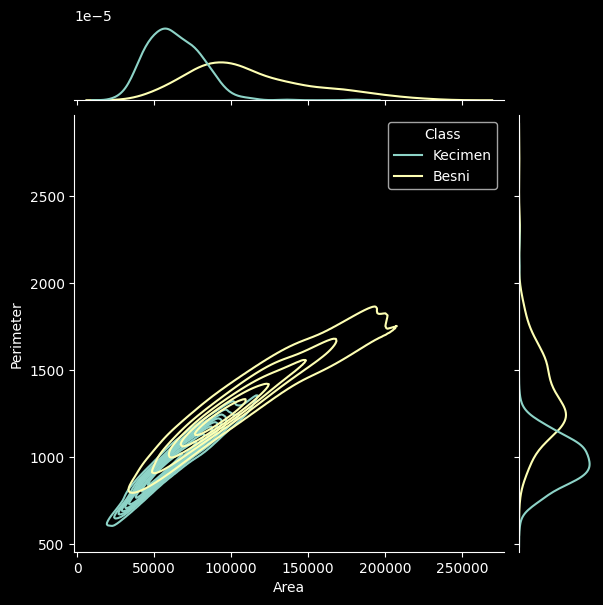

In [ ]:
sns.jointplot(data=df, x='Area', y='Perimeter', hue='Class', kind='kde')

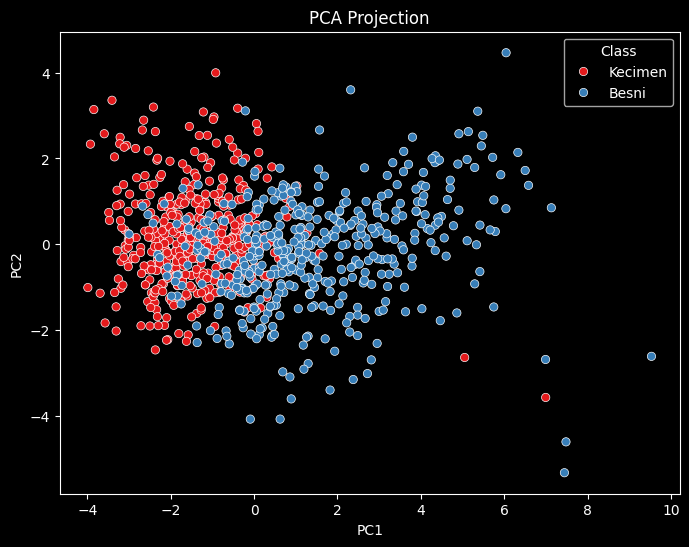

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X = df.drop('Class', axis=1)
y = df['Class']

X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
a
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=y, palette='Set1')
plt.title("PCA Projection")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

There are total 900 records and using all the features that we have available, we will build a classification model by using support vector machine

### Train Test Split

In [ ]:
X = df[["Area", "MajorAxisLength", "MinorAxisLength", "Eccentricity", "ConvexArea", "Extent", "Perimeter"]]
y = df["Class"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10)

### Model Training Using SVM: RBF Kernel

In [ ]:
from sklearn.svm import SVC

model = SVC(kernel="rbf")
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

from sklearn.metrics import classification_report

report = classification_report(y_test, y_pred)
print(report)

model.n_iter_

              precision    recall  f1-score   support

       Besni       0.86      0.75      0.80        83
     Kecimen       0.81      0.90      0.85        97

    accuracy                           0.83       180
   macro avg       0.83      0.82      0.82       180
weighted avg       0.83      0.83      0.83       180



array([229], dtype=int32)

### Model Training Using SVM: Linear Kernel

In [ ]:
from sklearn.svm import SVC

model = SVC(kernel="linear")
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

from sklearn.metrics import classification_report

report = classification_report(y_test, y_pred)
print(report)

model.n_iter_

              precision    recall  f1-score   support

       Besni       0.91      0.88      0.90        83
     Kecimen       0.90      0.93      0.91        97

    accuracy                           0.91       180
   macro avg       0.91      0.90      0.90       180
weighted avg       0.91      0.91      0.91       180



array([85005907], dtype=int32)